plotting ODES

### 4b (but only with NR1 step)

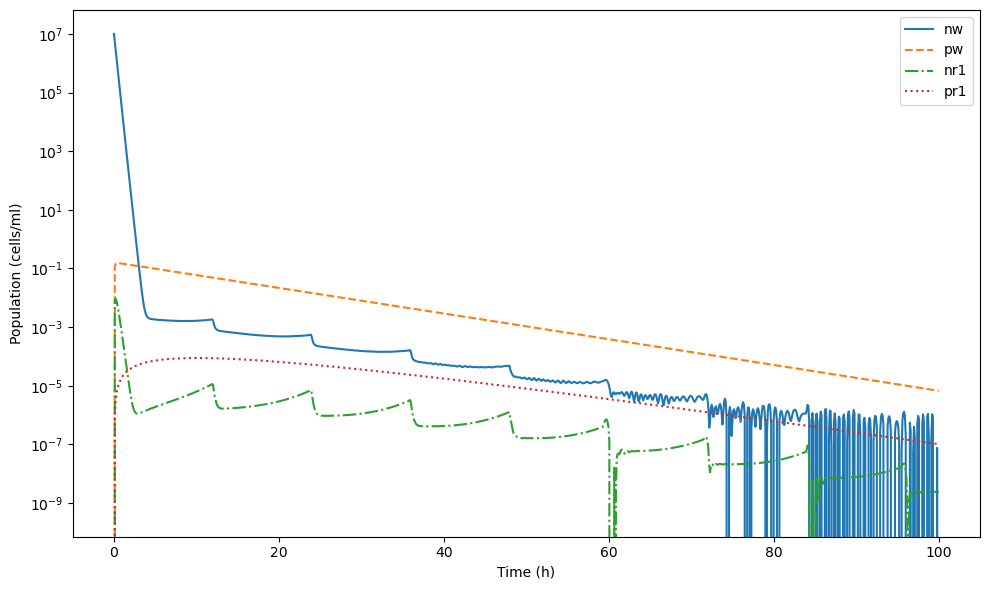

In [4]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

micWt = 1
micR1 = 4
gMax = 1.0
gMin = -6.5
hillKappa = 1
capacity = 5e9
aMax = 0.0001
bRate = 0.1
muWt = 1.5e-8
muP = 1.5e-4
decayRate = np.log(2) / 2.5
doseInterval = 12
aPeak = 25

immune = {
    'q': 3e-4,
    'emax': 1e6,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8
}

def drug(t):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growth(a, mic):
    return gMax - (gMax - gMin) * (a**hillKappa / (a**hillKappa + mic**hillKappa))

def system(t, y):
    nw, pw, nr1, pr1, e = y
    a = drug(t)
    total = nw + pw + nr1 + pr1
    aRate = aMax * total / capacity
    gNw = growth(a, micWt)
    gNr1 = growth(a, micR1)
    dNw = gNw * nw - aRate * nw + bRate * pw - muWt * nw - immune['jN'] * nw * e
    dPw = aRate * nw - bRate * pw - muP * pw - immune['jP'] * pw * e
    dNr1 = gNr1 * nr1 - aRate * nr1 + bRate * pr1 + muWt * nw - immune['jN'] * nr1 * e
    dPr1 = aRate * nr1 - bRate * pr1 + muP * pw - immune['jP'] * pr1 * e
    dE = immune['q'] * (immune['emax'] - e) - immune['l'] * e
    return [dNw, dPw, dNr1, dPr1, dE]

y0 = [1e7, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
plt.plot(sol.t, sol.y[0], label='nw', linestyle='-')
plt.plot(sol.t, sol.y[1], label='pw', linestyle='--')
plt.plot(sol.t, sol.y[2], label='nr1', linestyle='-.')
plt.plot(sol.t, sol.y[3], label='pr1', linestyle=':')
plt.yscale('log')
plt.xlabel('Time (h)')
plt.ylabel('Population (cells/ml)')
plt.legend()
plt.tight_layout()
plt.show()


### 4b implemented all NR1, NR2, NR3 steps

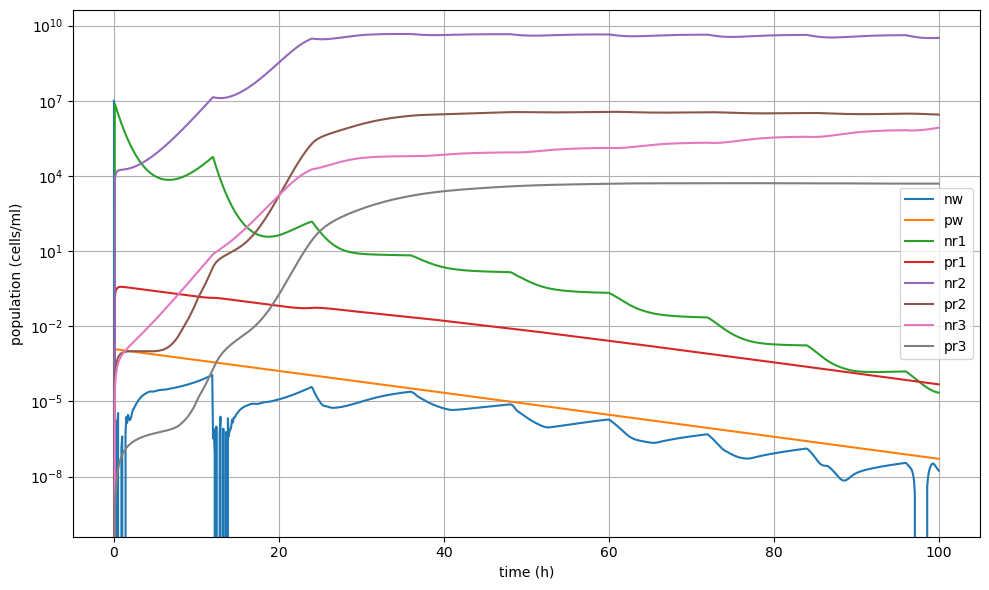

In [22]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],      # MIC values for wildtype and 3 resistant mutants
    'gMax': 1.0,                # Max growth rate of WT cells
    'gMin': -6.5,               # Minimum growth rate (when antibiotic is fully inhibitory)
    'gMaxR': 0.9,               # Max growth rate of Resister cells
    'kappa': 1,                 # Hill coefficient for drug effect
    'c': 5e9,                   # Carrying capacity
    'aMax': 1e-4,               # Rate of conversion from N to P under drug exposure
    'b': 0.1,                   # Rate of reversion from P to N
    'm': 1.5e-8,                # Basal mutation rate
    'tau': 2,                   # Coefficient for stress-induced mutagenesis
    'h': 5,                     # Exponent for stress response curve
    'muP': 1.5e-4,              # Mutation rate from persisters
    'immune': True,             # Whether immune response is enabled
    'mutation': True,           # Whether mutation is enabled
    'emax': 1e6,                # Max immune effector population
    'q': 3e-4,                  # Immune recruitment rate
    'l': 1e-3,                  # Immune inactivation rate
    'jN': 5e-6,                 # Immune killing of normal cells
    'jP': 5e-8,                 # Immune killing of persisters
    'aPeak': 25,                # Peak antibiotic concentration
    'doseInterval': 12,         # Antibiotic dosing interval (hours)
    'decayRate': np.log(2)/2.5  # Drug decay rate (half-life = 2.5h)
}

def drug(t, decayRate, doseInterval, aPeak):
    # Current drug concentration
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    # Growth inhibition
    return gMax - (gMax - gMin) * (a/mic)**kappa / ((a/mic)**kappa - (gMin/gMax))

def mutationRate(g, m, tau, h):
    # Stress induced mutation rate 
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMaxR = p['gMaxR']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak']) # Drug concentration
    aRate = p['aMax'] * total / p['c'] # Drug induced switching to persisters
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMaxR, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - muR2 * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + muR2 * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


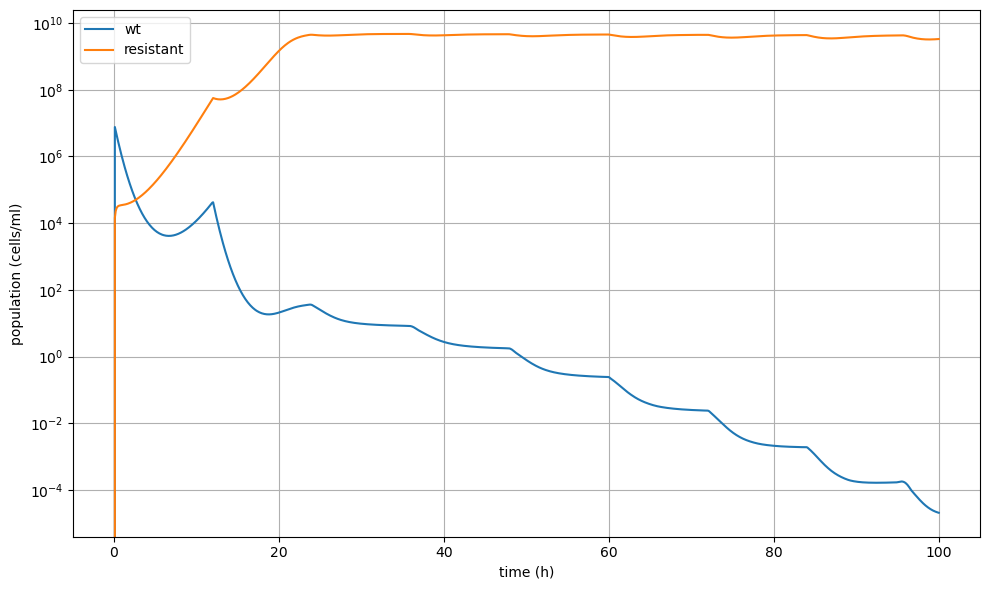

In [19]:
wt_total = sol.y[1] + sol.y[2]
rs_total = sol.y[3] + sol.y[4] + sol.y[5] + sol.y[6] + sol.y[7] + sol.y[8]

plt.figure(figsize=(10, 6))
plt.plot(sol.t, wt_total, label='wt')
plt.plot(sol.t, rs_total, label='resistant')
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### Before changing growth rate function

/var/folders/y8/tkwp24594js1pmrbn1t9h9tr0000gn/T/ipykernel_94253/1607774843.py:36: RuntimeWarning: overflow encountered in exp
  return m * g + tau * m * np.exp(-h * g)


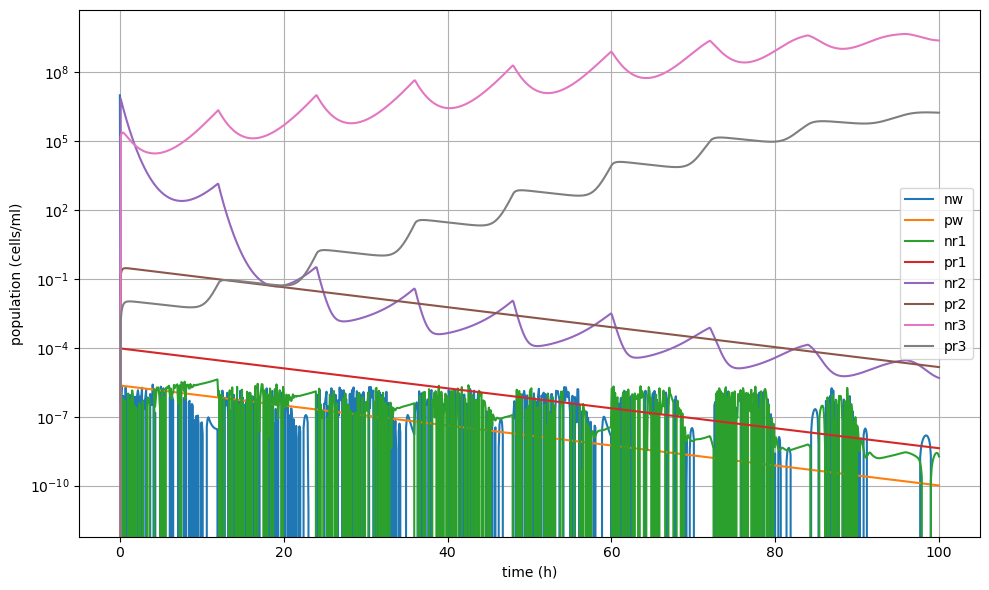

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

params = {
    'mic': [1, 4, 20, 50],
    'gMax': 1.0,
    'gMin': -6.5,
    'kappa': 1,
    'c': 5e9,
    'aMax': 0.0001,
    'b': 0.1,
    'm': 1.5e-8,
    'tau': 2,
    'h': 5,
    'muP': 1.5e-4,
    'immune': False,
    'mutation': True,
    'emax': 1e6,
    'q': 3e-4,
    'l': 1e-3,
    'jN': 5e-6,
    'jP': 5e-8,
    'aPeak': 25,
    'doseInterval': 12,
    'decayRate': np.log(2) / 2.5
}

def drug(t, decayRate, doseInterval, aPeak):
    return aPeak * np.exp(-decayRate * (t % doseInterval))

def growthRate(a, mic, gMax, gMin, kappa):
    return gMax - (gMax - gMin) * (a**kappa / (a**kappa + mic**kappa))

def mutationRate(g, m, tau, h):
    return m * g + tau * m * np.exp(-h * g)

def system(t, y, p):
    nw, pw, nr1, pr1, nr2, pr2, nr3, pr3, e = y
    mic = p['mic']
    gMax = p['gMax']
    gMin = p['gMin']
    total = nw + pw + nr1 + pr1 + nr2 + pr2 + nr3 + pr3
    a = drug(t, p['decayRate'], p['doseInterval'], p['aPeak'])
    aRate = p['aMax'] * total / p['c']
    b = p['b']

    gWt = growthRate(a, mic[0], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR1 = growthRate(a, mic[1], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR2 = growthRate(a, mic[2], gMax, gMin, p['kappa']) * (1 - total / p['c'])
    gR3 = growthRate(a, mic[3], gMax, gMin, p['kappa']) * (1 - total / p['c'])

    muW = mutationRate(gWt, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR1 = mutationRate(gR1, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muR2 = mutationRate(gR2, p['m'], p['tau'], p['h']) if p['mutation'] else 0
    muP = p['muP'] if p['mutation'] else 0

    jN = p['jN'] if p['immune'] else 0
    jP = p['jP'] if p['immune'] else 0

    dNw = gWt * nw - aRate * nw + b * pw - muW * nw - jN * nw * e
    dPw = aRate * nw - b * pw - muP * pw - jP * pw * e
    dNr1 = gR1 * nr1 - aRate * nr1 + b * pr1 + muW * nw - muR1 * nr1 - jN * nr1 * e
    dPr1 = aRate * nr1 - b * pr1 + muP * pw - muP * pr1 - jP * pr1 * e
    dNr2 = gR2 * nr2 - aRate * nr2 + b * pr2 + muR1 * nr1 - mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr2 * e
    dPr2 = aRate * nr2 - b * pr2 + muP * pr1 - muP * pr2 - jP * pr2 * e
    dNr3 = gR3 * nr3 - aRate * nr3 + b * pr3 + mutationRate(gR2, p['m'], p['tau'], p['h']) * nr2 - jN * nr3 * e
    dPr3 = aRate * nr3 - b * pr3 + muP * pr2 - jP * pr3 * e
    dE = p['q'] * (p['emax'] - e) - p['l'] * e if p['immune'] else 0

    return [dNw, dPw, dNr1, dPr1, dNr2, dPr2, dNr3, dPr3, dE]

y0 = [1e7, 0, 0, 0, 0, 0, 0, 0, 0]
tSpan = (0, 100)
tEval = np.linspace(*tSpan, 1000)

sol = solve_ivp(system, tSpan, y0, args=(params,), t_eval=tEval, method='RK45')

plt.figure(figsize=(10, 6))
labels = ['nw', 'pw', 'nr1', 'pr1', 'nr2', 'pr2', 'nr3', 'pr3']
for i in range(8):
    plt.plot(sol.t, sol.y[i], label=labels[i])
plt.yscale('log')
plt.xlabel('time (h)')
plt.ylabel('population (cells/ml)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
